In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_states = 16
n_actions = 4
goal_state = 15

Q_table = np.zeros((n_states, n_actions))


In [2]:
learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000


In [3]:
def get_next_state(state, action):
    row, col = divmod(state, 4)

    if action == 0 and col > 0:
        col -= 1
    elif action == 1 and col < 3:
        col += 1
    elif action == 2 and row > 0:
        row -= 1
    elif action == 3 and row < 3:
        row += 1

    return row * 4 + col


In [4]:
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states)

    while True:
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)

        reward = 1 if next_state == goal_state else 0

        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        if next_state == goal_state:
            break

        current_state = next_state


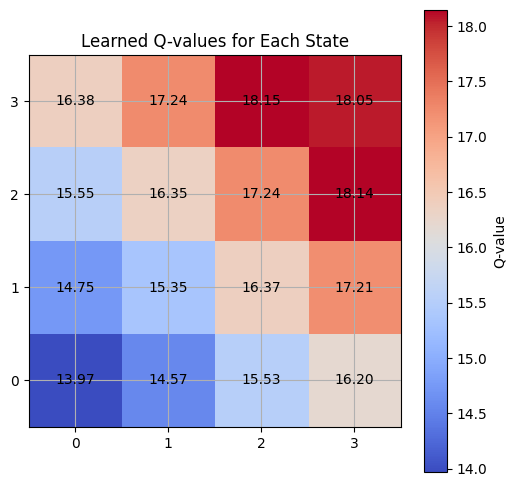

Learned Q-table:
[[ 5.29300843  8.50344947 11.40831308 13.97025791]
 [10.49998307 13.73674148 11.30095878 14.57091986]
 [13.0280181  12.8747729  13.31751182 15.53175347]
 [14.49976087 14.94609325 13.29736856 16.19703942]
 [13.65266289 14.24766711 12.81654855 14.7524665 ]
 [12.02802815 15.2982953  13.59360675 15.35001087]
 [13.95533124 16.06493393 14.33901525 16.3734142 ]
 [14.33117728 15.99775771 15.09921817 17.20714881]
 [14.22464871 15.44535667 13.78988295 15.55196088]
 [14.57852952 16.34932498 14.37492781 15.05979066]
 [15.26613157 17.15535102 15.19019857 17.23827053]
 [15.96753546 17.03561657 14.75775579 18.14246353]
 [15.16617326 16.37573496 14.28825757 15.36585701]
 [15.4733277  17.23823496 15.31594057 16.1166434 ]
 [16.28791604 18.14555531 16.27551676 17.03175244]
 [13.79062204  5.89454393 15.13895671 18.04795296]]


In [5]:
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(Q_table)
